In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_9_natural = get_prompt("natural", 9)

prompt_9_natural

'Simulate 1LYZ for 1ps at 300 K and for 1ps at 400K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute SASA and radius of gyration of the 300K simulation. Compute RMSD of both simulations.'

In [3]:
llm_model = "gpt-4o-2024-08-06"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_9_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: To address the question, I need to perform several tasks: download the PDB file for 1LYZ, set up and run simulations at 300 K and 400 K, compute secondary structure assignments, identify binding or active sites, compute SASA and radius of gyration for the 300 K simulation, and compute RMSD for both simulations. I'll start by downloading the PDB file for 1LYZ.

Action:
```
{
  "action": "PDBFileDownloader",
  "action_input": "1LYZ"
}
```PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_214604
Thought:

To proceed, I need to set up and run the simulations for 1LYZ at 300 K and 400 K. After that, I will analyze the secondary structure, binding sites, SASA, radius of gyration, and RMSD. I'll start by setting up and running the simulation at 300 K.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_214604",
    "forcefield_files": ["amber99sb.xml", "tip3p.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1.0 * nanometers",
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": 0.00001,
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 5,
      "record_pa

About to create system...
Attempts at creating system: 0/3
Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_214604', 'forcefield_files': ['amber99sb.xml', 'tip3p.xml'], 'save': True, 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1.0 * nanometers', 'constraints': 'HBonds', 'rigidWater': True, 'constraintTolerance': 1e-05, 'solvate': True}, 'integrator_params': {'integrator_type': 'LangevinMiddle', 'Temperature': '300 *

Thought: The error indicates that there is an issue with missing atoms in the LYS residue, which is preventing the simulation from running. To resolve this, I need to clean the PDB file by adding missing atoms and hydrogens, and replacing any nonstandard residues. After cleaning, I will attempt to set up and run the simulation again.

Action:
```json
{
  "action": "CleaningToolFunction",
  "action_input": {
    "pdb_id": "1LYZ_214604",
    "replace_nonstandard_residues": true,
    "add_missing_atoms": true,
    "remove_heterogens": true,
    "remove_water": true,
    "add_hydrogens": true,
    "add_hydrogens_ph": 7.0
  }
}
```file path: /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_22/pdb/1LYZ_raw_20251222_214604.pdb


...

Calculating RMSD...
Data saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_22/records/rmsd_1LYZ.csv
Plot saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_22/figures/FIG_rmsd_1LYZ_20251222_224218.png

Observation: Succeeded. RMSD calculated and saved to csv with file ID rmsd_1LYZ. Plot saved with plot ID fig0_224218. 
Thought:

To complete the task, I need to compute the RMSD for the 400 K simulation. Once this is done, I will have all the necessary analyses to provide a comprehensive final answer. I'll proceed by computing the RMSD for the 400 K simulation.

Action:
```json
{
  "action": "ComputeRMSD",
  "action_input": {
    "top_id": "top_sim0_220053",
    "traj_id": "rec0_220059",
    "select": "protein",
    "mol_name": "1LYZ"
  }
}
```

Calculating RMSD...
Data saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_22/records/rmsd_1LYZ_1.csv
Plot saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_22/figures/FIG_rmsd_1LYZ_20251222_224221.png

Observation: Succeeded. RMSD calculated and saved to csv with file ID rmsd_1LYZ_1. Plot saved with plot ID fig0_224221. 
Thought:

Action:
```json
{
  "action": "Final Answer",
  "action_input": "The simulation and analysis for the protein 1LYZ have been completed as follows:\n\n1. **Secondary Structure Assignments**: \n   - Residues in helix: 50\n   - Residues in strand: 14\n   - Residues in coil: 65\n\n2. **Known Sites**:\n   - Active Sites: Residues at positions 53 and 71.\n   - No known binding sites or other relevant sites.\n\n3. **300 K Simulation**:\n   - **SASA**: Computed and saved with File ID sasa_1LYZ.\n   - **Radius of Gyration**: Average value is 3.45 nm. Results saved with ID rgy_rec0_214619.\n   - **RMSD**: Calculated and saved with File ID rmsd_1LYZ.\n\n4. **400 K Simulation**:\n   - **RMSD**: Calculated and saved with File ID rmsd_1LYZ_1.\n\nAll plots and data files have been saved for further analysis."
}
```

> Finished chain.
({'input': '\n    You are an expert molecular dynamics scientist, and\n    your task is to respond to the question or\n    solve the problem to the best of your ability u

<Figure size 640x480 with 0 Axes>

In [3]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_214604: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_214604
 1LYZ_214611: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_214613: Initial positions for simulation sim0_214613
 sim0_214613: Basic Simulation of Protein 1LYZ_214611
 rec0_214619: Simulation trajectory for protein 1LYZ_214611 and simulation sim0_214613
 rec1_214619: Simulation state log for protein 1LYZ_214611 and simulation sim0_214613
 rec2_214619: Simulation pdb frames for protein 1LYZ_214611 and simulation sim0_214613
 top_sim0_220053: Initial positions for simulation sim0_220053
 sim0_220053: Basic Simulation of Protein 1LYZ_214611
 rec0_220059: Simulation trajectory for protein 1LYZ_214611 and simulation sim0_220053
 rec1_220059: Simulation state log for protein 1LYZ_214611 and simulation sim0_220053
 rec2_220059: Simulation pdb frames for protein 1LYZ_2146

In [4]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_214604"))

In [5]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_214604", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [6]:
# make sure trajectory and topology exist
traj_path_1 = registry.get_mapped_path("rec0_214619")
top_path_1 = registry.get_mapped_path("top_sim0_214613")

assert os.path.exists(traj_path_1)
assert os.path.exists(top_path_1)

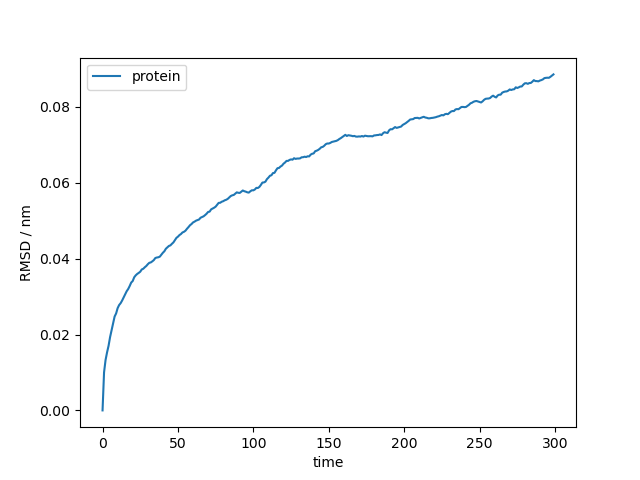

In [7]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_224218'))

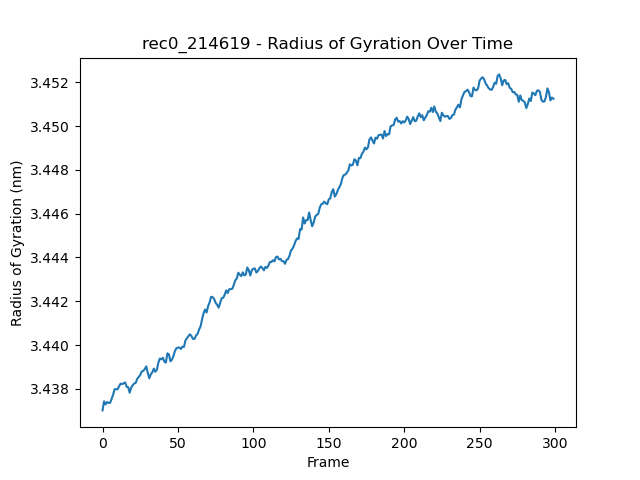

In [9]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_224215'))

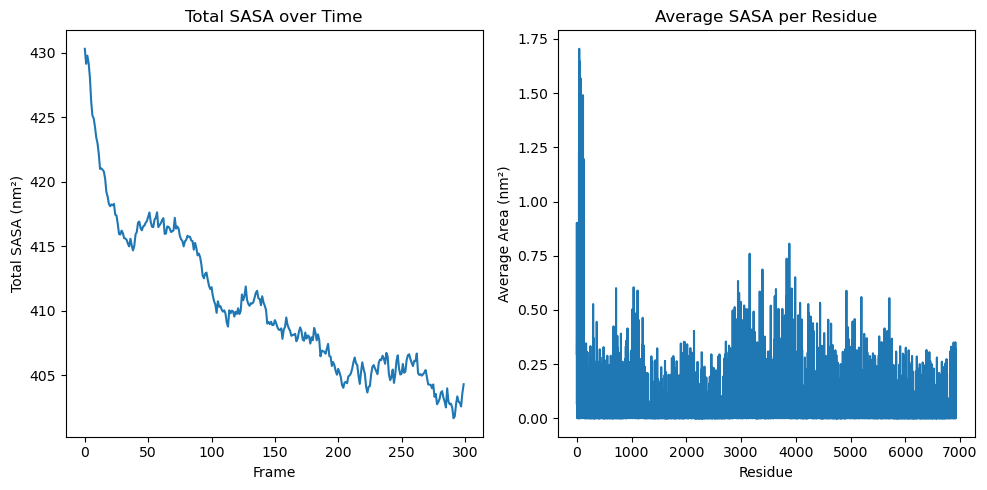

In [10]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_224211'))

In [11]:
# make sure trajectory and topology exist (sim2)
traj_path_2 = registry.get_mapped_path("rec0_220059")
top_path_2 = registry.get_mapped_path("top_sim0_220053")

assert os.path.exists(traj_path_2)
assert os.path.exists(top_path_2)

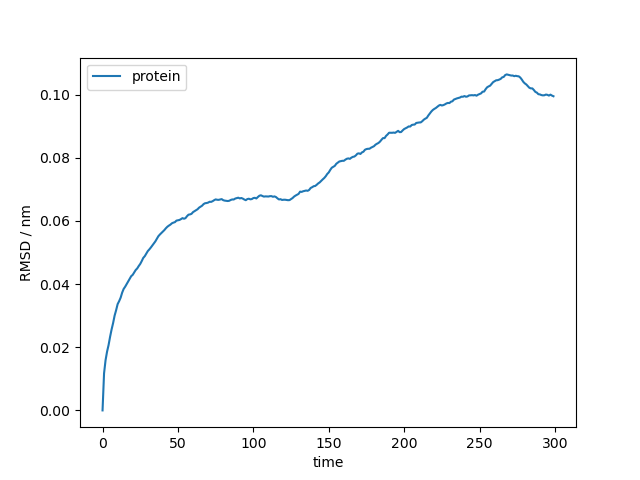

In [8]:
# make sure rmsd plot was generated (sim2)
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_224221'))

In [16]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 111433
Output tokens: 2155
LLM costs: $ 0.300133
